In [1]:
import pandas as pd 
import numpy as np

from sklearn.datasets import load_iris
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.preprocessing import LabelEncoder
from sklearn.svm import SVC
from sklearn.utils import resample
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# import ensemble methods
from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression

# Import metrics for F1-score, Precision, Recall (CRITICAL for this challenge!)
from sklearn.metrics import f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import precision_score, recall_score, accuracy_score, precision_recall_curve

import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
# setting Jedha color palette as default
pio.templates["jedha"] = go.layout.Template(
    layout_colorway=["#4B9AC7", "#4BE8E0", "#9DD4F3", "#97FBF6", "#2A7FAF", "#23B1AB", "#0E3449", "#015955"]
)
pio.templates.default = "jedha"
pio.renderers.default = "svg" # to be replaced by "iframe" if working on JULIE

import warnings
warnings.filterwarnings("ignore") # to avoid warnings

In [2]:
df = pd.read_csv("conversion_data_train.csv")
df.head()

,country,age,new_user,source,total_pages_visited,converted
0,China,22,1,Direct,2,0
1,UK,21,1,Ads,3,0
2,Germany,20,0,Seo,14,1
3,US,23,1,Seo,3,0
4,US,28,1,Direct,3,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284580 entries, 0 to 284579
Data columns (total 6 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   country              284580 non-null  object
 1   age                  284580 non-null  int64 
 2   new_user             284580 non-null  int64 
 3   source               284580 non-null  object
 4   total_pages_visited  284580 non-null  int64 
 5   converted            284580 non-null  int64 
dtypes: int64(4), object(2)
memory usage: 13.0+ MB


In [4]:
df.describe(include='all')

,country,age,new_user,source,total_pages_visited,converted
count,284580,284580.000000,284580.000000,284580,284580.000000,284580.000000
unique,4,NaN,NaN,3,NaN,NaN
top,US,NaN,NaN,Seo,NaN,NaN
freq,160124,NaN,NaN,139477,NaN,NaN
mean,NaN,30.564203,0.685452,NaN,4.873252,0.032258
std,NaN,8.266789,0.464336,NaN,3.341995,0.176685
min,NaN,17.000000,0.000000,NaN,1.000000,0.000000
25%,NaN,24.000000,0.000000,NaN,2.000000,0.000000
50%,NaN,30.000000,1.000000,NaN,4.000000,0.000000
75%,NaN,36.000000,1.000000,NaN,7.000000,0.000000


In [5]:
df.shape

(284580, 6)

In [6]:
convert = df.groupby("country")["converted"].agg(["count", "sum"])
convert = convert.rename(columns={"count": "total_users", "sum": "converted"})
convert

,total_users,converted
country,,
China,69122,89
Germany,11693,730
UK,43641,2291
US,160124,6070


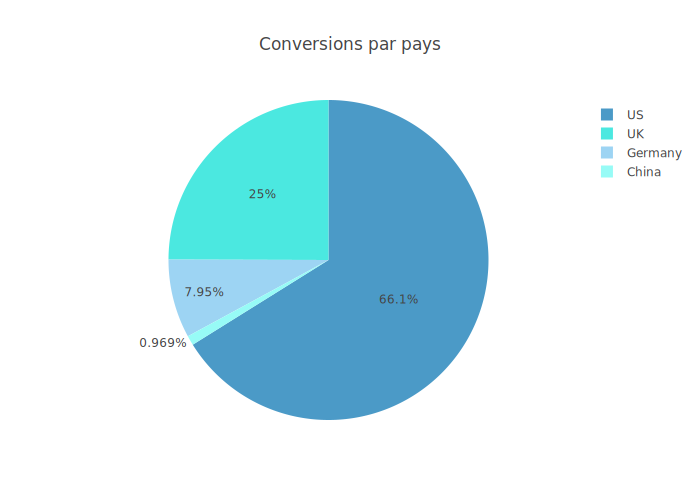

In [7]:
fig = px.pie(
    values=convert["converted"],
    names=convert.index,
    title="Conversions par pays"
)

fig.show()

In [ ]:
X = df.drop("converted", axis=1)
y = df["converted"]
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify = y, random_state = 56) #rs=5 de base 

In [9]:
numeric_features = ["age", "total_pages_visited"]
categorical_features = ["country", "new_user", "source"]

print('Found numeric features:', numeric_features)
print('Found categorical features:', categorical_features)

Found numeric features: ['age', 'total_pages_visited']
Found categorical features: ['country', 'new_user', 'source']


In [10]:
# Pipeline for numeric features
numeric_transformer = Pipeline(steps=[
    ('imputer', KNNImputer()), 
    ('scaler', StandardScaler())
])

# Create pipeline for categorical features
categorical_transformer = Pipeline(
    steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')), # missing values will be replaced by most frequent value
    ('encoder', OneHotEncoder(drop='first')) # first column will be dropped to avoid creating correlations between features
    ])

# Use ColumnTransformer to make a preprocessor object that describes all the treatments to be done
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

In [11]:
# Preprocessings on train set
print("Performing preprocessings on train set...")
print(X_train.head())
X_train = preprocessor.fit_transform(X_train)
print('...Done.')
print(X_train[0:5]) 
print()

# Preprocessings on test set
print("Performing preprocessings on test set...")
print(X_test.head()) 
X_test = preprocessor.transform(X_test) # Don't fit again !! 
print('...Done.')
print(X_test[0:5,:])

Performing preprocessings on train set...
       country  age  new_user  source  total_pages_visited
69014    China   26         0     Ads                    2
262260      US   21         0     Seo                    7
78664    China   23         1     Seo                    8
101748      US   31         0     Seo                    3
158949      US   25         0  Direct                    3
...Done.
[[-0.55264961 -0.86055209  0.          0.          0.          0.
   0.          0.        ]
 [-1.15758061  0.63654972  0.          0.          1.          0.
   0.          1.        ]
 [-0.91560821  0.93597008  0.          0.          0.          1.
   0.          1.        ]
 [ 0.05228139 -0.56113173  0.          0.          1.          0.
   0.          1.        ]
 [-0.67363581 -0.56113173  0.          0.          1.          0.
   1.          0.        ]]

Performing preprocessings on test set...
       country  age  new_user  source  total_pages_visited
257065   China   17         

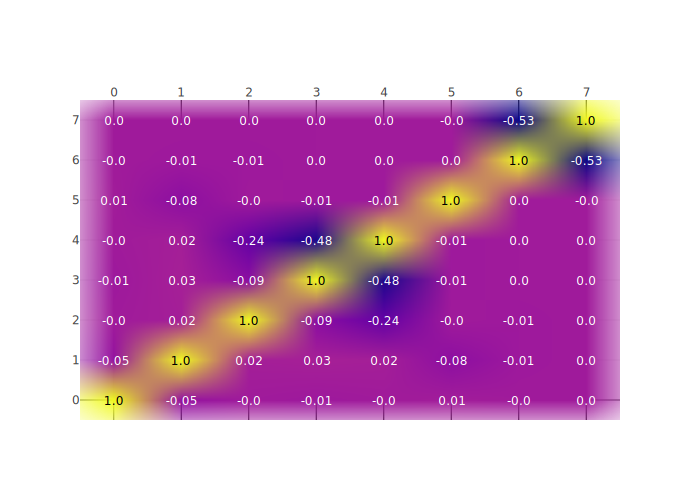

In [12]:
# Correlation matrix
corr_matrix = pd.DataFrame(X_train).corr().round(2)

import plotly.figure_factory as ff

fig = ff.create_annotated_heatmap(corr_matrix.values,
                                  x = corr_matrix.columns.tolist(),
                                  y = corr_matrix.index.tolist())


fig.show()

In [13]:
# PART 1: BASELINE MODEL (Simple Logistic Regression)

print("BASELINE MODEL: Logistic Regression")

# Train baseline model
baseline = LogisticRegression(max_iter=1000)
baseline.fit(X_train, y_train)

# Predictions
y_train_pred_baseline = baseline.predict(X_train)
y_test_pred_baseline = baseline.predict(X_test)

# F1-scores
baseline_train_f1 = f1_score(y_train, y_train_pred_baseline)
baseline_test_f1 = f1_score(y_test, y_test_pred_baseline)

print(f"\nBaseline F1-score (train): {baseline_train_f1:.4f}")
print(f"Baseline F1-score (test):  {baseline_test_f1:.4f}")

print("\n Baseline établi, Objectif: dépasser ce F1-score avec les modèles optimisés")

BASELINE MODEL: Logistic Regression

Baseline F1-score (train): 0.7565
Baseline F1-score (test):  0.7790

 Baseline établi, Objectif: dépasser ce F1-score avec les modèles optimisés


In [20]:
# LogisticRegression optimized
print("Train model...")
logreg = LogisticRegression(max_iter=1000, C=100)
logreg.fit(X_train, y_train)
print("...Done.")

# Prédictions (une seule fois)
y_train_pred = logreg.predict(X_train)
y_test_pred = logreg.predict(X_test)

# Calcul des métriques
train_f1 = f1_score(y_train, y_train_pred)
test_f1 = f1_score(y_test, y_test_pred)
train_precision = precision_score(y_train, y_train_pred)
test_precision = precision_score(y_test, y_test_pred)
train_recall = recall_score(y_train, y_train_pred)
test_recall = recall_score(y_test, y_test_pred)

# Affichage
print(f"TRAIN | F1: {train_f1:.4f} | Precision: {train_precision:.4f} | Recall: {train_recall:.4f}")
print(f"TEST  | F1: {test_f1:.4f} | Precision: {test_precision:.4f} | Recall: {test_recall:.4f}")



Train model...
...Done.
TRAIN | F1: 0.7570 | Precision: 0.8499 | Recall: 0.6825
TEST  | F1: 0.7809 | Precision: 0.8785 | Recall: 0.7028


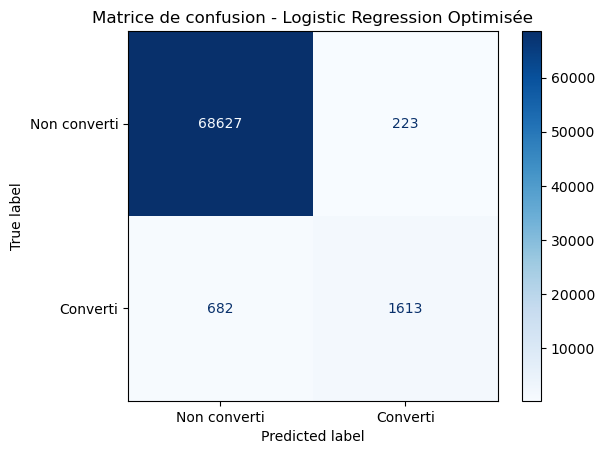

In [15]:
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non converti', 'Converti'])
disp.plot(cmap='Blues')
plt.title('Matrice de confusion - Logistic Regression Optimisée')
plt.show()

In [21]:
# Modèle XGBoost
model = XGBClassifier(max_depth=5, n_jobs=-1, eval_metric='logloss', verbosity=0)
model.fit(X_train, y_train)

# Prédictions
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# Calcul des métriques
train_f1 = f1_score(y_train, y_train_pred)
test_f1 = f1_score(y_test, y_test_pred)
train_precision = precision_score(y_train, y_train_pred)
test_precision = precision_score(y_test, y_test_pred)
train_recall = recall_score(y_train, y_train_pred)
test_recall = recall_score(y_test, y_test_pred)

# Affichage
print(f"TRAIN | F1: {train_f1:.4f} | Precision: {train_precision:.4f} | Recall: {train_recall:.4f}")
print(f"TEST  | F1: {test_f1:.4f} | Precision: {test_precision:.4f} | Recall: {test_recall:.4f}")

TRAIN | F1: 0.7657 | Precision: 0.8451 | Recall: 0.6999
TEST  | F1: 0.7792 | Precision: 0.8650 | Recall: 0.7089


In [16]:
# PART 3: PRÉDICTIONS SUR LE FICHIER TEST (pour soumission)

print("PART 3: PRÉDICTIONS SUR DATA_TEST.CSV")

# Charger le fichier test
df_test = pd.read_csv("conversion_data_test.csv")
print(f"\nFichier test chargé: {df_test.shape[0]} lignes")

# Préparer X_submission
features = ['country', 'age', 'new_user', 'total_pages_visited', "source"]
X_submission = df_test[features]

# Appliquer le preprocessing
X_submission_processed = preprocessor.transform(X_submission)

# Générer les prédictions
y_submission_pred = logreg.predict(X_submission_processed)

print(f"Prédictions générées: {len(y_submission_pred)}")
print(f"Conversions prédites: {y_submission_pred.sum()} ({y_submission_pred.mean()*100:.1f}%)")

# Créer le fichier de soumission
submission = pd.DataFrame({
    'id': df_test.index,
    'converted': y_submission_pred
})

submission.to_csv("pred_julien_charlierV2.3.csv", index=False)
print(f"\nFichier 'pred_julien_charlierV2.3.csv' créé avec {len(submission)} prédictions")

PART 3: PRÉDICTIONS SUR DATA_TEST.CSV

Fichier test chargé: 31620 lignes
Prédictions générées: 31620
Conversions prédites: 818 (2.6%)

Fichier 'pred_julien_charlierV2.3.csv' créé avec 31620 prédictions
